In [15]:
!pip install ultralytics opencv-python pillow matplotlib accelerate


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
!pip install git+https://github.com/huggingface/transformers

  Cloning https://github.com/huggingface/transformers to C:\Users\SWEMa\AppData\Local\Temp\pip-req-build-byat2jw4
  Resolved https://github.com/huggingface/transformers to commit db9f18c370c92e971172e69bc9a88854947d9fc5
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11353964 sha256=fa33d696385595862340978f658746f12aaf45bd051b32f752174bda5592482f
  Stored in directory: C:\Users\SWEMa\AppData\Local\Temp\pip-ephem-wheel-cache-fri7c4ee\wheels\2b\de\48\1c5b158806820c3979e1dc7a341b68dac1231f00b1a2c9442f
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.4.0
    

  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers 'C:\Users\SWEMa\AppData\Local\Temp\pip-req-build-byat2jw4'

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Cloning https://github.com/huggingface/transformers to C:\Users\SWEMa\AppData\Local\Temp\pip-req-build-vv4x59za
  Resolved https://github.com/huggingface/transformers to commit db9f18c370c92e971172e69bc9a88854947d9fc5
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers 'C:\Users\SWEMa\AppData\Local\Temp\pip-req-build-vv4x59za'

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:

import sys
import os

sys.path.append(os.path.abspath(".."))

import cv2
import matplotlib.pyplot as plt

from utils.plate_detector import PlateDetector
from utils.plate_enhancer import PlateEnhancer
from utils.plate_reader import PlateReader

In [2]:
def show_img(img, title="image", figsize=(8,4)):
    if img is None:
        print("Image is None")
        return

    plt.figure(figsize=figsize)

    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()

In [3]:
project_root = os.path.abspath("..")

image_path = os.path.join(
    project_root,
    "test_images",
    "WhatsApp Image 2026-04-01 at 8.14.29 PM.jpeg"
)

model_path = os.path.join(
    project_root,
    "models",
    "plate_detector",
    "best.pt"
)

output_dir = os.path.join(project_root, "outputs")
os.makedirs(output_dir, exist_ok=True)

print("image exists:", os.path.exists(image_path))
print("model exists:", os.path.exists(model_path))

detector = PlateDetector(model_path)
enhancer = PlateEnhancer(scale=3)
reader = PlateReader()

image exists: True
model exists: True


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.



0: 960x448 1 license_plate, 443.5ms
Speed: 49.6ms preprocess, 443.5ms inference, 20.2ms postprocess per image at shape (1, 3, 960, 448)


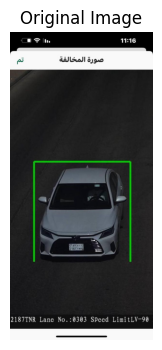

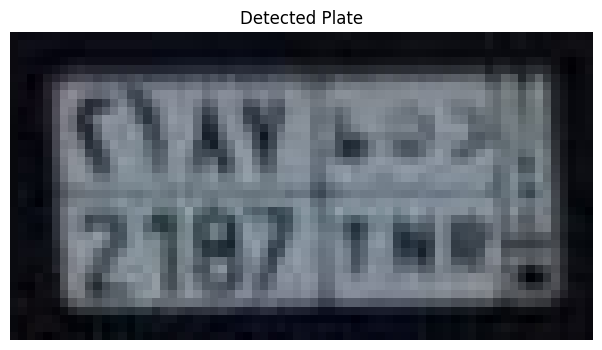

plate shape: (37, 70, 3)


In [4]:
original_img, plate = detector.detect_plate_with_padding(image_path)

show_img(original_img, "Original Image")

if plate is None:
    print("No plate detected")
else:
    show_img(plate, "Detected Plate")
    print("plate shape:", plate.shape)

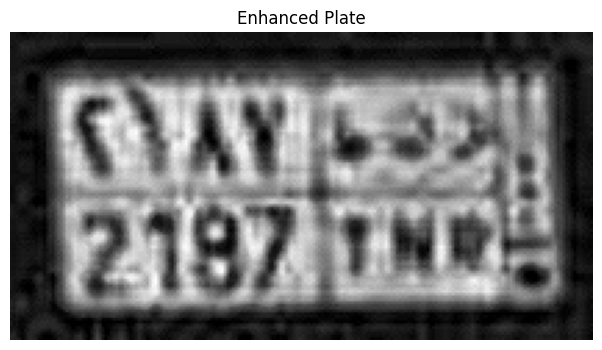

saved to: c:\Users\SWEMa\Desktop\computer-vision-project-visionx\outputs\enhanced_plate.png


In [5]:
enhanced = enhancer.enhance_plate_for_qwen(plate)

show_img(enhanced, "Enhanced Plate")

enhanced_path = os.path.join(output_dir, "enhanced_plate.png")
cv2.imwrite(enhanced_path, enhanced)

print("saved to:", enhanced_path)

In [6]:
result = reader.read_and_parse(enhanced_path)

print("RAW OUTPUT:")
print(result["raw"])
print()
print("DIGITS:", result["digits"])
print("LETTERS:", result["letters"])
print("FINAL:", result["final"])

RAW OUTPUT:
DIGITS: 2187
LETTERS: TNR
FINAL: 2187 TNR

DIGITS: 2187
LETTERS: TNR
FINAL: 2187 TNR
